# Creative Model: Global LightGBM

This notebook trains a global LightGBM model across all store-category series. It can be run as a standalone file — all data loading, preprocessing, and feature engineering are included.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/paveenavijayakumar/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/paveenavijayakumar/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/paveenavijayakumar/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    se

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/paveenavijayakumar/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/paveenavijayakumar/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/paveenavijayakumar/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    se

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/paveenavijayakumar/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/paveenavijayakumar/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/paveenavijayakumar/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    se

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/paveenavijayakumar/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/paveenavijayakumar/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/paveenavijayakumar/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    se

AttributeError: _ARRAY_API not found

## Load and Prepare Data

In [2]:
# load data
df = pd.read_csv('sales_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Total rows: {len(df):,}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')

Total rows: 76,000
Date range: 2022-01-01 to 2024-01-30


In [3]:
# aggregate to store x category level
store_cat = df.groupby(['Date', 'Store ID', 'Category'])['Units Sold'].sum().reset_index()
store_cat = store_cat.sort_values(['Store ID', 'Category', 'Date']).reset_index(drop=True)

HOLDOUT       = 28
SHORT_HORIZON = 5
LONG_HORIZON  = 28

print(f'Number of series: {store_cat.groupby(["Store ID", "Category"]).ngroups}')
print(f'Holdout: {HOLDOUT} days | Short horizon: {SHORT_HORIZON} days | Long horizon: {LONG_HORIZON} days')

Number of series: 24
Holdout: 28 days | Short horizon: 5 days | Long horizon: 28 days


## Set Parameters

In [4]:
RANDOM_STATE = 42
TARGET       = 'Units Sold'
N_CV_ORIGINS = 15
CV_STEP_DAYS = 7

## Merge Exogenous Features

We merge back Promotion, Discount, Competitor Pricing, Weather, Epidemic, and Seasonality from the original dataset onto the store-category aggregation.

In [5]:
sales_data = store_cat.copy()

meta_cols  = ['Date', 'Store ID', 'Category', 'Promotion', 'Discount',
              'Competitor Pricing', 'Weather Condition', 'Epidemic', 'Seasonality']
exog_meta  = df[meta_cols].drop_duplicates(subset=['Date', 'Store ID', 'Category'])
sales_data = sales_data.merge(exog_meta, on=['Date', 'Store ID', 'Category'], how='left')

sales_data['Date']      = pd.to_datetime(sales_data['Date'])
sales_data              = sales_data.sort_values(['Store ID', 'Category', 'Date']).reset_index(drop=True)
sales_data['series_id'] = sales_data['Store ID'] + '_' + sales_data['Category']

print(f'Total rows: {len(sales_data):,}')
print(f'Date range: {sales_data["Date"].min().date()} to {sales_data["Date"].max().date()}')
print(f'Number of store-category series: {sales_data["series_id"].nunique()}')

Total rows: 18,240
Date range: 2022-01-01 to 2024-01-30
Number of store-category series: 24


## Feature Engineering

We create three groups of features:
- **Lag features**: past values of Units Sold at lags 1, 2, 3, 7, 14, 21, 28. These give the model memory of recent demand.
- **Rolling statistics**: rolling means and standard deviations computed from past data. These capture recent demand trends and volatility.
- **Exogenous features**: Promotion, Discount, Competitor Pricing, Weather, Epidemic. These are all known ahead of time.
- **Time features**: day of week, month, week of year. These help the model learn calendar-based patterns.
- **Static features**: Store ID, Category, Region. These let the model distinguish between different store-category series.

In [6]:
def create_lag_features(df, target_col=TARGET):
    """
    Creates lag and rolling features grouped by series_id.
    All lags use shift(1) minimum so we never leak the current value.
    """
    df  = df.copy().sort_values(['series_id', 'Date'])
    grp = df.groupby('series_id')[target_col]

    # lag features
    for lag in [1, 2, 3, 7, 14, 21, 28]:
        df[f'lag_{lag}'] = grp.shift(lag)

    # rolling means (shift 1 to avoid leaking current value)
    for window in [7, 14, 28]:
        df[f'rolling_mean_{window}'] = grp.shift(1).transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )

    # rolling std (volatility signal)
    for window in [7, 14]:
        df[f'rolling_std_{window}'] = grp.shift(1).transform(
            lambda x: x.rolling(window, min_periods=2).std()
        )

    # time features
    df['day_of_week']  = df['Date'].dt.dayofweek
    df['month']        = df['Date'].dt.month
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    df['day_of_month'] = df['Date'].dt.day
    df['quarter']      = df['Date'].dt.quarter
    df['is_weekend']   = (df['Date'].dt.dayofweek >= 5).astype(int)

    # encode categorical static features
    cat_cols = [col for col in ['Store ID', 'Category', 'Region', 'Weather Condition', 'Seasonality'] if col in df.columns]
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))
        encoders[col]    = le

    return df, encoders


sales_data, encoders = create_lag_features(sales_data)

# define feature groups
static_features  = [f'{col}_enc' for col in ['Store ID', 'Category', 'Region'] if f'{col}_enc' in sales_data.columns]
time_features    = ['day_of_week', 'month', 'week_of_year', 'day_of_month', 'quarter', 'is_weekend']
lag_features     = [f'lag_{d}' for d in [1, 2, 3, 7, 14, 21, 28]]
rolling_features = ['rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28',
                    'rolling_std_7', 'rolling_std_14']
exog_features    = [col for col in ['Promotion', 'Discount', 'Competitor Pricing', 'Epidemic', 'Weather Condition_enc']
                    if col in sales_data.columns]

ALL_FEATURES = static_features + time_features + lag_features + rolling_features + exog_features
print(f'Total features: {len(ALL_FEATURES)}')
print(ALL_FEATURES)

Total features: 25
['Store ID_enc', 'Category_enc', 'day_of_week', 'month', 'week_of_year', 'day_of_month', 'quarter', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_std_7', 'rolling_std_14', 'Promotion', 'Discount', 'Competitor Pricing', 'Epidemic', 'Weather Condition_enc']


## Train / Test Split

We hold out the last 28 days as a completely unseen test set. This is a strict temporal holdout — the model never sees any test data during training or cross-validation.

In [7]:
# drop rows where lag features are NaN (first ~30 rows per series)
df_model = sales_data.dropna(subset=lag_features).reset_index(drop=True)

# hold out the last LONG_HORIZON observations for each store-category series
valid_series = df_model.groupby('series_id').size().loc[lambda x: x >= LONG_HORIZON].index
if len(valid_series) != df_model['series_id'].nunique():
    print(f'Removing {df_model["series_id"].nunique() - len(valid_series)} series with fewer than {LONG_HORIZON} observations after lagging.')
df_model = df_model[df_model['series_id'].isin(valid_series)].reset_index(drop=True)

test_df  = df_model.groupby('series_id', group_keys=False).tail(LONG_HORIZON).reset_index(drop=True)
train_df = df_model.drop(test_df.index).reset_index(drop=True)

test_cutoff = train_df['Date'].max()

X_train = train_df[ALL_FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[ALL_FEATURES]
y_test  = test_df[TARGET]

print(f'Training rows: {len(train_df):,}   ({train_df["Date"].min().date()} to {train_df["Date"].max().date()})')
print(f'Test rows    : {len(test_df):,}   ({test_df["Date"].min().date()} to {test_df["Date"].max().date()})')
print(f'Training covers all {train_df["series_id"].nunique()} store-category series')

Training rows: 16,896   (2022-01-29 to 2024-01-30)
Test rows    : 672   (2024-01-03 to 2024-01-30)
Training covers all 24 store-category series


## Train the Global LightGBM Model

We use early stopping on a small validation slice (last 60 days of training) to prevent overfitting. The final model is then retrained on all training data using the best number of estimators found.

In [8]:
LGBM_PARAMS = {
    'objective'        : 'regression_l1',
    'metric'           : 'mae',
    'learning_rate'    : 0.05,
    'num_leaves'       : 63,
    'min_child_samples': 20,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'n_estimators'     : 1000,
    'random_state'     : RANDOM_STATE,
    'verbose'          : -1
}

# use last 60 days of training as an internal validation set for early stopping
val_cutoff  = test_cutoff - pd.Timedelta(days=60)
inner_train = train_df[train_df['Date'] <= val_cutoff]
inner_val   = train_df[train_df['Date'] >  val_cutoff]

model_es = lgb.LGBMRegressor(**LGBM_PARAMS)
model_es.fit(
    inner_train[ALL_FEATURES], inner_train[TARGET],
    eval_set=[(inner_val[ALL_FEATURES], inner_val[TARGET])],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

best_n_estimators = model_es.best_iteration_
print(f'Best number of estimators from early stopping: {best_n_estimators}')

# retrain on full training set
LGBM_PARAMS_FINAL = {**LGBM_PARAMS, 'n_estimators': best_n_estimators}
model = lgb.LGBMRegressor(**LGBM_PARAMS_FINAL)
model.fit(X_train, y_train)
print('Final model trained on full training set.')

[100]	valid_0's l1: 59.0725
[200]	valid_0's l1: 58.4335
Best number of estimators from early stopping: 215
Final model trained on full training set.


## Evaluation Metrics

We compute MAE, RMSE, MAPE, and WMAPE at both the 5-day and 28-day horizons to match the other models in the report.

In [9]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mae   = np.mean(np.abs(y_true - y_pred))
    rmse  = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape  = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    denom = np.sum(np.abs(y_true))
    wmape = np.sum(np.abs(y_true - y_pred)) / denom * 100 if denom != 0 else np.nan

    return {
        'MAE'  : round(mae,   2),
        'RMSE' : round(rmse,  2),
        'MAPE' : round(mape,  2),
        'WMAPE': round(wmape, 2),
    }

## Test Set Results

In [10]:
test_preds = model.predict(X_test)

# 28-day metrics
m_28 = compute_metrics(y_test.values, test_preds)

# 5-day metrics (first SHORT_HORIZON days of each series holdout)
short_df    = test_df.sort_values(['series_id', 'Date']).groupby('series_id').head(SHORT_HORIZON)
short_preds = model.predict(short_df[ALL_FEATURES])
m_5         = compute_metrics(short_df[TARGET].values, short_preds)

summary = pd.DataFrame([{
    'MAE_5d'   : m_5['MAE'],    'RMSE_5d'  : m_5['RMSE'],    'MAPE_5d'  : m_5['MAPE'],    'WMAPE_5d'  : m_5['WMAPE'],
    'MAE_28d'  : m_28['MAE'],   'RMSE_28d' : m_28['RMSE'],   'MAPE_28d' : m_28['MAPE'],   'WMAPE_28d' : m_28['WMAPE'],
}])

print('Overall test set metrics (all series):')
print(summary.T.rename(columns={0: 'Global LightGBM'}).to_string())

Overall test set metrics (all series):
           Global LightGBM
MAE_5d               32.31
RMSE_5d              49.69
MAPE_5d              17.05
WMAPE_5d             12.43
MAE_28d              44.95
RMSE_28d             69.73
MAPE_28d             15.86
WMAPE_28d            12.70


## Per-Series Metrics

In [11]:
results = []
for sid in sorted(test_df['series_id'].unique()):
    series_test = test_df[test_df['series_id'] == sid].sort_values('Date')
    preds_28    = model.predict(series_test[ALL_FEATURES])

    short_test  = series_test.head(SHORT_HORIZON)
    preds_5     = model.predict(short_test[ALL_FEATURES])

    m_28 = compute_metrics(series_test[TARGET].values, preds_28)
    m_5  = compute_metrics(short_test[TARGET].values, preds_5)

    store, category = sid.split('_', 1)
    results.append({
        'Store'    : store,
        'Category' : category,
        'MAE_5d'   : m_5['MAE'],    'RMSE_5d'  : m_5['RMSE'],    'MAPE_5d'  : m_5['MAPE'],
        'MAE_28d'  : m_28['MAE'],   'RMSE_28d' : m_28['RMSE'],   'MAPE_28d' : m_28['MAPE'],
    })

series_df = pd.DataFrame(results)
print('Per-series metrics (mean across all series):')
print(series_df.drop(columns=['Store', 'Category']).mean().round(2))
print()
print('Best 5 series by 28-day MAE:')
print(series_df.sort_values('MAE_28d').head(5).to_string(index=False))
print()
print('Worst 5 series by 28-day MAE:')
print(series_df.sort_values('MAE_28d', ascending=False).head(5).to_string(index=False))

Per-series metrics (mean across all series):
MAE_5d      32.31
RMSE_5d     41.38
MAPE_5d     17.05
MAE_28d     44.95
RMSE_28d    62.44
MAPE_28d    15.86
dtype: float64

Best 5 series by 28-day MAE:
Store    Category  MAE_5d  RMSE_5d  MAPE_5d  MAE_28d  RMSE_28d  MAPE_28d
 S002   Furniture    1.58     2.53     4.41    12.69     17.91     23.72
 S005    Clothing   13.20    20.76    16.56    17.22     25.36     22.38
 S004 Electronics    9.95    12.98    16.71    19.44     29.91     27.73
 S003   Furniture   10.31    13.46    12.19    23.20     34.33     12.58
 S005   Furniture   10.03    12.24    12.25    23.39     40.70     14.54

Worst 5 series by 28-day MAE:
Store  Category  MAE_5d  RMSE_5d  MAPE_5d  MAE_28d  RMSE_28d  MAPE_28d
 S003 Groceries   54.14    64.75     8.92    90.34    115.54     10.28
 S002 Groceries   42.18    58.55     7.62    85.56    116.19     11.23
 S005 Groceries   82.46    91.47    10.67    80.59    119.51      7.95
 S004  Clothing   64.60    96.24     9.56    80.3

## Rolling Origin Cross-Validation

Rolling origin CV gives a more stable estimate of performance than a single holdout split. At each origin we train on all data up to that point, then evaluate on the next 5 and 28 days. We use 15 origins spaced 7 days apart.

In [12]:
def rolling_origin_cv(df, feature_cols, target_col, params,
                      n_origins=N_CV_ORIGINS, step_days=CV_STEP_DAYS,
                      h_short=SHORT_HORIZON, h_long=LONG_HORIZON):
    """
    Rolling origin cross-validation for the global LightGBM model.
    Returns a DataFrame with MAE at each origin for both short and long horizons.
    """
    max_train_date = df['Date'].max() - pd.Timedelta(days=h_long)
    end_origin     = max_train_date - pd.Timedelta(days=h_long)
    start_origin   = end_origin - pd.Timedelta(days=step_days * (n_origins - 1))
    cutoffs        = pd.date_range(start=start_origin, end=end_origin, freq=f'{step_days}D')

    results = []
    for cutoff in cutoffs:
        train_cv  = df[df['Date'] <= cutoff].dropna(subset=feature_cols)
        val_short = df[(df['Date'] > cutoff) &
                       (df['Date'] <= cutoff + pd.Timedelta(days=h_short))].dropna(subset=feature_cols)
        val_long  = df[(df['Date'] > cutoff) &
                       (df['Date'] <= cutoff + pd.Timedelta(days=h_long))].dropna(subset=feature_cols)

        if len(train_cv) == 0 or len(val_short) == 0 or len(val_long) == 0:
            continue

        m = lgb.LGBMRegressor(**params)
        m.fit(train_cv[feature_cols], train_cv[target_col])

        mae_short = mean_absolute_error(val_short[target_col], m.predict(val_short[feature_cols]))
        mae_long  = mean_absolute_error(val_long[target_col],  m.predict(val_long[feature_cols]))

        results.append({'Origin': cutoff.date(), 'Horizon': f'{h_short}-day', 'MAE': mae_short})
        results.append({'Origin': cutoff.date(), 'Horizon': f'{h_long}-day',  'MAE': mae_long})
        print(f'  Origin {cutoff.date()}: MAE {h_short}-day = {mae_short:.2f}, MAE {h_long}-day = {mae_long:.2f}')

    return pd.DataFrame(results)


print('Running rolling origin cross-validation...')
cv_results = rolling_origin_cv(df_model, ALL_FEATURES, TARGET, LGBM_PARAMS_FINAL)

print('\nCV Summary (mean MAE per horizon):')
cv_summary = cv_results.groupby('Horizon')['MAE'].agg(['mean', 'std', 'min', 'max']).round(2)
print(cv_summary)

Running rolling origin cross-validation...
  Origin 2023-08-29: MAE 5-day = 66.56, MAE 28-day = 56.13
  Origin 2023-09-05: MAE 5-day = 49.87, MAE 28-day = 53.84
  Origin 2023-09-12: MAE 5-day = 53.13, MAE 28-day = 56.02
  Origin 2023-09-19: MAE 5-day = 54.63, MAE 28-day = 52.50
  Origin 2023-09-26: MAE 5-day = 55.24, MAE 28-day = 49.85
  Origin 2023-10-03: MAE 5-day = 61.31, MAE 28-day = 52.02
  Origin 2023-10-10: MAE 5-day = 39.37, MAE 28-day = 52.00
  Origin 2023-10-17: MAE 5-day = 40.85, MAE 28-day = 54.85
  Origin 2023-10-24: MAE 5-day = 75.28, MAE 28-day = 57.95
  Origin 2023-10-31: MAE 5-day = 59.64, MAE 28-day = 55.14
  Origin 2023-11-07: MAE 5-day = 50.93, MAE 28-day = 55.64
  Origin 2023-11-14: MAE 5-day = 58.71, MAE 28-day = 59.31
  Origin 2023-11-21: MAE 5-day = 53.55, MAE 28-day = 59.69
  Origin 2023-11-28: MAE 5-day = 58.58, MAE 28-day = 61.29
  Origin 2023-12-05: MAE 5-day = 61.84, MAE 28-day = 59.30

CV Summary (mean MAE per horizon):
          mean   std    min    max
H

## Visualisations

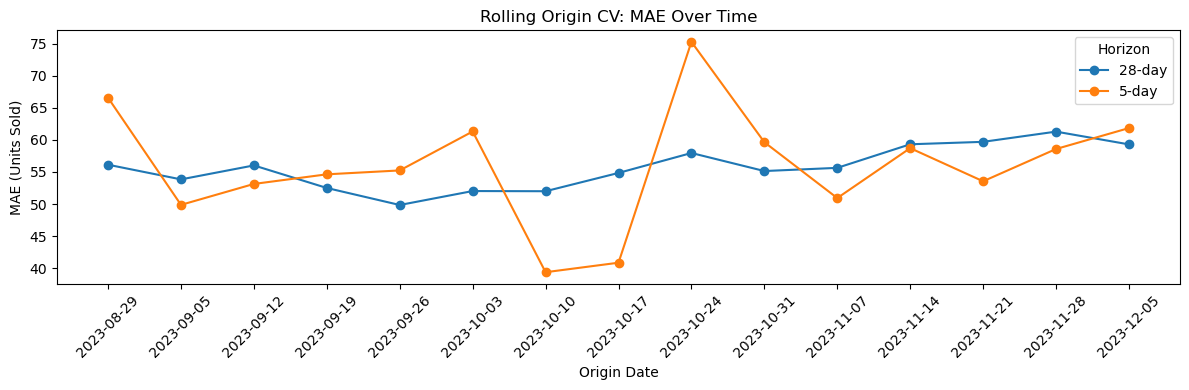

In [13]:
# rolling origin CV MAE over time
fig, ax = plt.subplots(figsize=(12, 4))
for horizon, grp in cv_results.groupby('Horizon'):
    ax.plot(grp['Origin'].astype(str), grp['MAE'], marker='o', label=horizon)

ax.set_title('Rolling Origin CV: MAE Over Time')
ax.set_xlabel('Origin Date')
ax.set_ylabel('MAE (Units Sold)')
ax.legend(title='Horizon')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

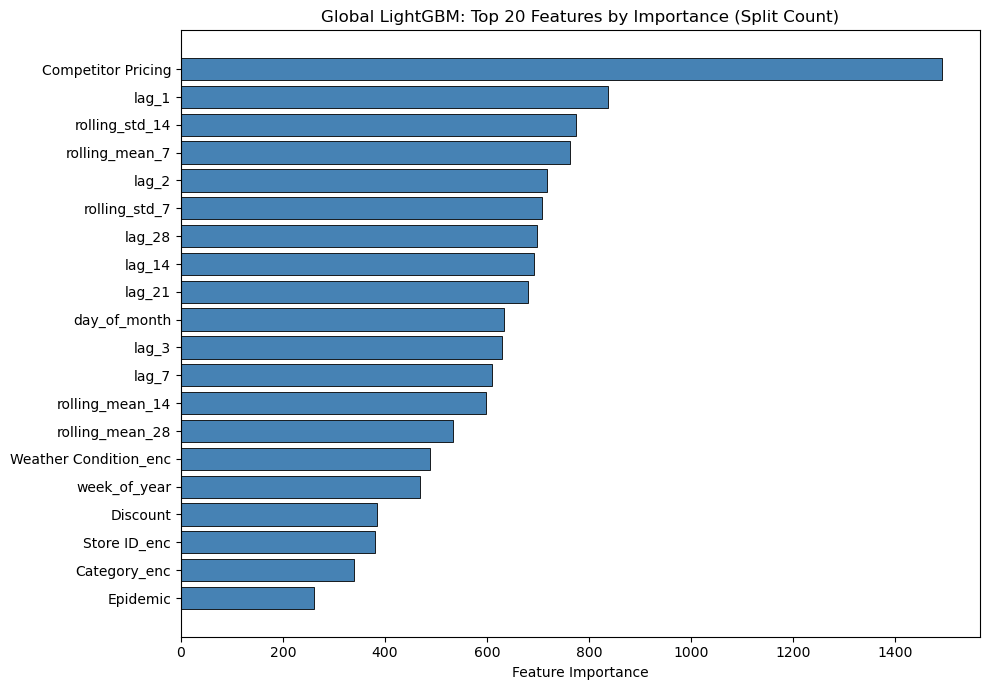

In [14]:
# feature importance
importance_df = pd.DataFrame({
    'Feature'   : ALL_FEATURES,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
        color='steelblue', edgecolor='black', linewidth=0.6)
ax.set_title('Global LightGBM: Top 20 Features by Importance (Split Count)')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.show()

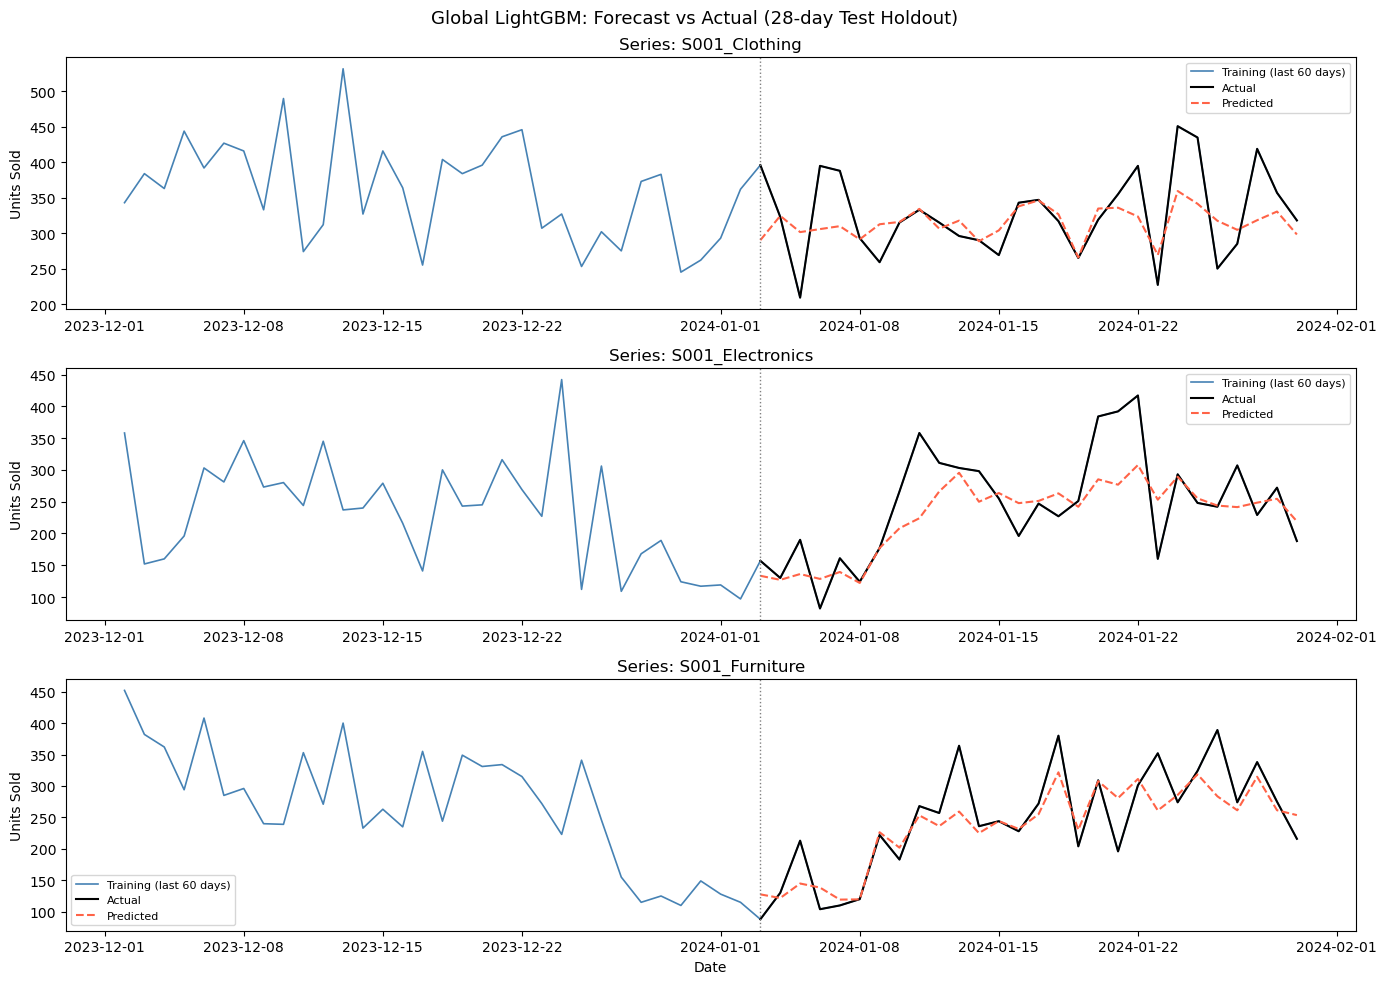

In [15]:
# forecast vs actual for 3 sample series
sample_series = sorted(test_df['series_id'].unique())[:3]
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, sid in zip(axes, sample_series):
    train_tail  = train_df[train_df['series_id'] == sid].tail(60)
    test_series = test_df[test_df['series_id'] == sid]
    preds       = model.predict(test_series[ALL_FEATURES])

    ax.plot(train_tail['Date'], train_tail[TARGET],
            color='steelblue', label='Training (last 60 days)', linewidth=1.2)
    ax.plot(test_series['Date'], test_series[TARGET],
            color='black', label='Actual', linewidth=1.5)
    ax.plot(test_series['Date'], preds,
            color='tomato', linestyle='--', label='Predicted', linewidth=1.5)
    ax.axvline(test_series['Date'].min(), color='grey', linestyle=':', linewidth=1)
    ax.set_title(f'Series: {sid}')
    ax.set_ylabel('Units Sold')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Date')
fig.suptitle('Global LightGBM: Forecast vs Actual (28-day Test Holdout)', fontsize=13)
plt.tight_layout()
plt.show()

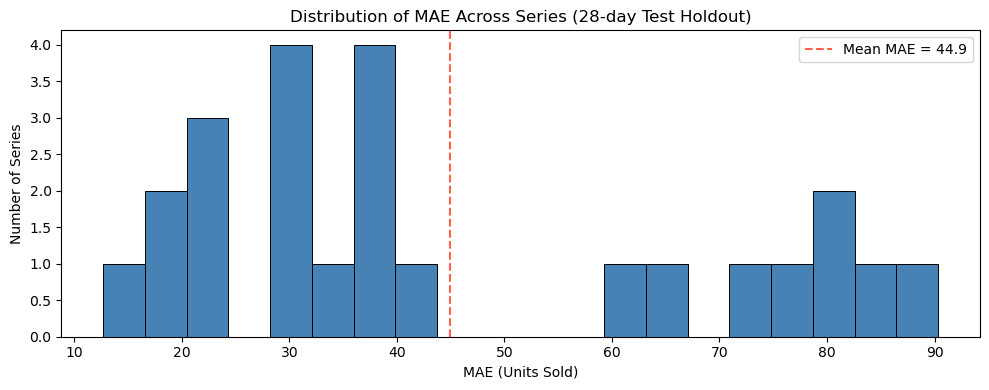

In [16]:
# per-series MAE distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(series_df['MAE_28d'], bins=20, color='steelblue', edgecolor='black', linewidth=0.7)
ax.axvline(series_df['MAE_28d'].mean(), color='tomato', linestyle='--',
           linewidth=1.5, label=f"Mean MAE = {series_df['MAE_28d'].mean():.1f}")
ax.set_title('Distribution of MAE Across Series (28-day Test Holdout)')
ax.set_xlabel('MAE (Units Sold)')
ax.set_ylabel('Number of Series')
ax.legend()
plt.tight_layout()
plt.show()

## Business-Relevant Metric: Asymmetric Cost

Stockouts and overstock are not equally costly in retail. A stockout means a lost sale (revenue loss), while excess inventory leads to holding costs and markdowns. We assign a penalty ratio of 2:1 (under-forecast costs twice as much as over-forecast) and compute a weighted cost metric.

In [17]:
def asymmetric_cost(y_true, y_pred, under_penalty=2.0, over_penalty=1.0):
    """
    Asymmetric cost metric.
    Penalises under-forecasting (stockout risk) more than over-forecasting.
    """
    y_true  = np.array(y_true, dtype=float)
    y_pred  = np.array(y_pred, dtype=float)
    errors  = y_pred - y_true
    cost    = np.where(errors < 0,
                       under_penalty * np.abs(errors),
                       over_penalty  * np.abs(errors))
    return np.mean(cost)


# naive seasonal benchmark: use lag_7 as the forecast
naive_preds = test_df['lag_7'].values
valid_mask  = ~np.isnan(naive_preds)

lgbm_cost  = asymmetric_cost(y_test.values, test_preds)
naive_cost = asymmetric_cost(y_test.values[valid_mask], naive_preds[valid_mask])

print(f'Asymmetric Cost (2:1 penalty) -- Global LightGBM : {lgbm_cost:.2f}')
print(f'Asymmetric Cost (2:1 penalty) -- Naive Seasonal  : {naive_cost:.2f}')
print(f'Improvement over naive        : {((naive_cost - lgbm_cost) / naive_cost * 100):.1f}%')

Asymmetric Cost (2:1 penalty) -- Global LightGBM : 73.13
Asymmetric Cost (2:1 penalty) -- Naive Seasonal  : 159.38
Improvement over naive        : 54.1%
